Gerando e preparando os dados de transações...

Total de transações analisadas: 1000
Total de fraudes/anomalias detectadas: 10


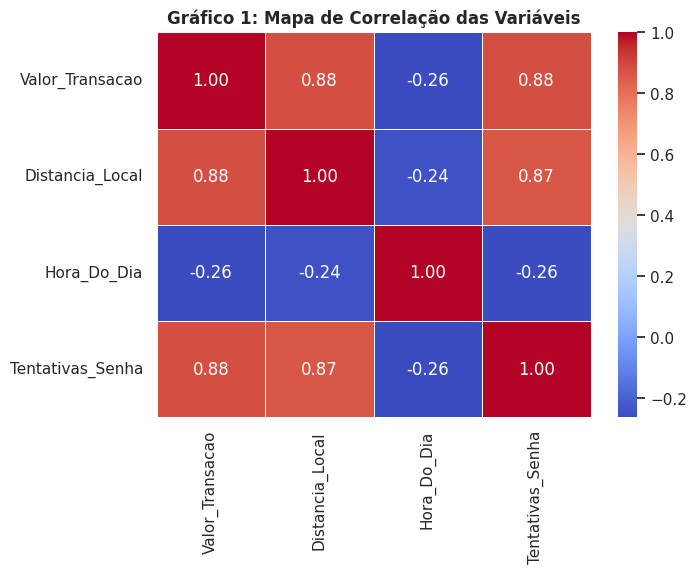

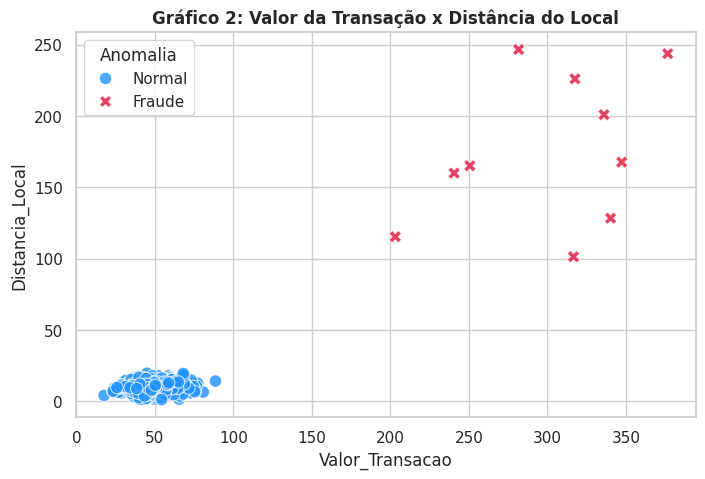

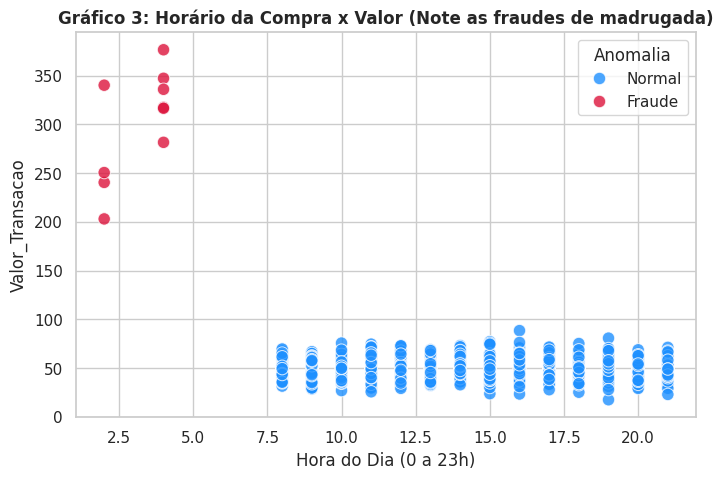

/tmp/ipykernel_2455/969330572.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


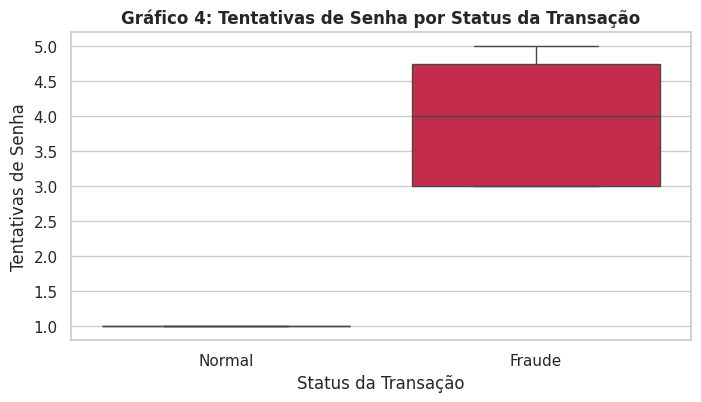

/tmp/ipykernel_2455/969330572.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


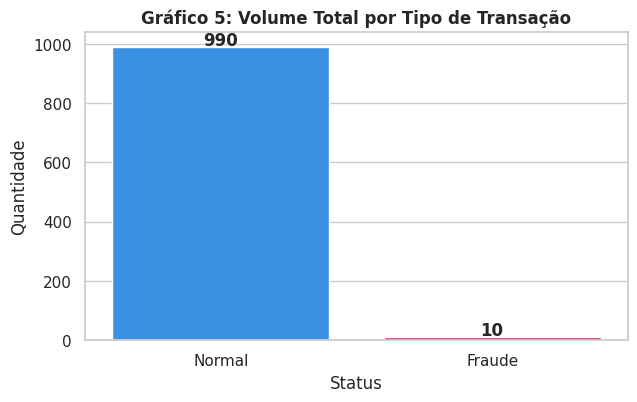

In [9]:
# ==========================================
# PROJETO: Detecção de Anomalias em Transações
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Deixando o visual dos gráficos moderno e limpo
sns.set_theme(style="whitegrid")

# 1. GERANDO DADOS DE TRANSAÇÕES (Com 4 variáveis)
print("Gerando e preparando os dados de transações...")
np.random.seed(42)

normais_val = np.random.normal(50, 10, 990)
normais_dist = np.random.normal(10, 3, 990)
normais_hora = np.random.randint(8, 22, 990)
normais_tent = np.ones(990)

fraudes_val = np.random.uniform(200, 400, 10)
fraudes_dist = np.random.uniform(100, 250, 10)
fraudes_hora = np.random.choice([2, 3, 4], 10)
fraudes_tent = np.random.randint(3, 6, 10)

df = pd.DataFrame({
    'Valor_Transacao': np.concatenate([normais_val, fraudes_val]),
    'Distancia_Local': np.concatenate([normais_dist, fraudes_dist]),
    'Hora_Do_Dia': np.concatenate([normais_hora, fraudes_hora]),
    'Tentativas_Senha': np.concatenate([normais_tent, fraudes_tent])
})

# 2. NORMALIZAÇÃO E MODELAGEM (Isolation Forest)
scaler = StandardScaler()
X_escalado = scaler.fit_transform(df)

# 'contamination=0.01' define que esperamos cerca de 1% de anomalias/fraudes
modelo = IsolationForest(contamination=0.01, random_state=42)
df['previsao'] = modelo.fit_predict(X_escalado)
df['Anomalia'] = df['previsao'].apply(lambda x: 'Fraude' if x == -1 else 'Normal')

total_fraudes = len(df[df['Anomalia'] == 'Fraude'])
total_normais = len(df[df['Anomalia'] == 'Normal'])

print(f"\nTotal de transações analisadas: {len(df)}")
print(f"Total de fraudes/anomalias detectadas: {total_fraudes}")


# ==========================================
# SEÇÃO COM OS 5 GRÁFICOS "CHIQUES"
# ==========================================

# Gráfico 1: Mapa de Calor (Correlação entre as colunas)
plt.figure(figsize=(7, 5))
sns.heatmap(df.drop(columns=['previsao', 'Anomalia']).corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Gráfico 1: Mapa de Correlação das Variáveis', fontsize=12, fontweight='bold')
plt.show()

# Gráfico 2: Dispersão (Valor x Distância)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, x='Valor_Transacao', y='Distancia_Local',
    hue='Anomalia', palette={'Normal': 'dodgerblue', 'Fraude': 'crimson'},
    style='Anomalia', s=80, alpha=0.8
)
plt.title('Gráfico 2: Valor da Transação x Distância do Local', fontsize=12, fontweight='bold')
plt.show()

# Gráfico 3: Dispersão (Hora do Dia x Valor)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, x='Hora_Do_Dia', y='Valor_Transacao',
    hue='Anomalia', palette={'Normal': 'dodgerblue', 'Fraude': 'crimson'},
    s=80, alpha=0.8
)
plt.title('Gráfico 3: Horário da Compra x Valor (Note as fraudes de madrugada)', fontsize=12, fontweight='bold')
plt.xlabel('Hora do Dia (0 a 23h)')
plt.show()

# Gráfico 4: Boxplot de Tentativas de Senha
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=df, x='Anomalia', y='Tentativas_Senha',
    palette={'Normal': 'dodgerblue', 'Fraude': 'crimson'}
)
plt.title('Gráfico 4: Tentativas de Senha por Status da Transação', fontsize=12, fontweight='bold')
plt.xlabel('Status da Transação')
plt.ylabel('Tentativas de Senha')
plt.show()

# Gráfico 5: Gráfico de Barras (Contagem de Transações Normais vs Fraudes)
plt.figure(figsize=(7, 4))
ax = sns.countplot(
    data=df, x='Anomalia',
    palette={'Normal': 'dodgerblue', 'Fraude': 'crimson'}
)
plt.title('Gráfico 5: Volume Total por Tipo de Transação', fontsize=12, fontweight='bold')
plt.xlabel('Status')
plt.ylabel('Quantidade')

# Adicionando os números exatos em cima de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points',
                fontweight='bold')

plt.show()